In [12]:
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
adc_out_filepath = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/static_data/RAMPbatch_25x8192_1MHz_hi2.8V_lo0.7V_high_power.csv"

df = pd.read_csv(adc_out_filepath)
df.head()

,test_1,test_2,test_3,test_4,test_5,test_6,test_7,test_8,test_9,test_10,...,test_16,test_17,test_18,test_19,test_20,test_21,test_22,test_23,test_24,test_25
0,240,255,195,215,245,250,54,32,65,119,...,54,105,241,49,54,0,93,150,105,27
1,255,255,222,241,255,255,89,65,98,148,...,86,133,255,82,89,27,123,184,133,56
2,8,22,250,255,13,20,119,98,125,179,...,115,164,8,111,119,54,153,212,164,89
3,34,54,255,8,41,52,148,125,158,203,...,145,195,34,142,148,89,184,236,195,121
4,61,85,17,34,73,82,179,158,188,230,...,178,219,63,174,179,121,212,255,219,151


In [14]:
import numpy as np

# get your histogram as arrays, not a plot
counts, bin_edges = np.histogram(df, bins=256, range=(0, 255))

# counts[i] = number of occurrences of code i
# ignore code 0 and code 255 (first and last)
valid_counts = counts[1:-1]   # codes 1 through 254

# average height Hm across valid codes
N_valid = len(valid_counts)   # 254 codes
N_total = valid_counts.sum()  # total samples in valid range
Hm = N_total / N_valid        # expected count per code if perfectly linear

# DNL[i] = (counts[i] - Hm) / Hm   in units of LSB
DNL = (valid_counts - Hm) / Hm

# INL = cumulative sum of DNL
INL = np.cumsum(DNL)

print(f"Hm = {Hm:.2f}")
print(f"DNL max = {DNL.max():.4f} LSB,  min = {DNL.min():.4f} LSB")
print(f"INL max = {INL.max():.4f} LSB,  min = {INL.min():.4f} LSB")

Hm = 716.89
DNL max = 4.7945 LSB,  min = -1.0000 LSB
INL max = 2.8855 LSB,  min = -8.8806 LSB


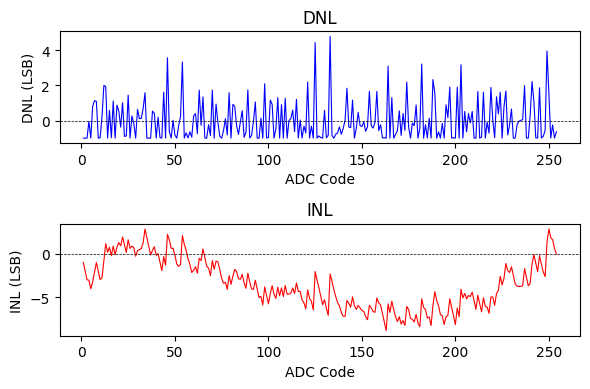

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(6, 4))

codes = np.arange(1, 255)   # codes 1 through 254

axes[0].plot(codes, DNL, color="blue", linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title("DNL")
axes[0].set_xlabel("ADC Code")
axes[0].set_ylabel("DNL (LSB)")

axes[1].plot(codes, INL, color="red", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_title("INL")
axes[1].set_xlabel("ADC Code")
axes[1].set_ylabel("INL (LSB)")

plt.tight_layout()
plt.show()